# Measles in the United States: abrupt break or gradual decline

This example applies *bayesloop* to a question from epidemiology. Measles is one of the
great success stories of public health: a vaccine was licensed in 1963 and the United
States declared the disease eliminated in 2000. The textbook narrative is a clean
before/after story, but it is not obvious whether the vaccine's epidemiological
signature was really an *abrupt* break or a *gradual* multi-year decline as coverage
accumulated. A related question is whether the transition can be dated from the data
alone, without assuming when it happened.

These are questions *bayesloop* is built for. Rather than fitting one static model, we
let the transmission level vary in time and use the marginal likelihood (model
evidence) as an objective, complexity-penalised score to ask the data which kind of
variation it prefers. In the course of the analysis we use a good part of the toolbox:
`Study`, `HyperStudy` and `ChangepointStudy`; the `Gaussian` and custom `NumPy`
observation models; and the `Static`, `GaussianRandomWalk`, `AlphaStableRandomWalk`,
`ChangePoint`, `CombinedTransitionModel` and `RegimeSwitch` transition models.

In [1]:
import io
import urllib.request

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import bayesloop as bl

# A consistent, publication-leaning style for the figures below.
try:
    import seaborn as sns
    sns.set_style("whitegrid")
except ImportError:
    plt.style.use("default")
mpl.rcParams.update({
    "figure.dpi": 110, "font.size": 10.5, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.edgecolor": "#444444", "grid.color": "#d9d9d9",
})
C = {"data": "#8a8a8a", "accent": "#c1272d", "accent2": "#0b6e99", "green": "#2e7d32"}


# Two small helpers to turn a fitted study into a posterior mean and credible band for
# a time-varying parameter. (bayesloop also has built-in plotting via ``S.plot``; these
# give us a bit more control over the figures.)
def posterior_band(S, name, lo=0.05, hi=0.95):
    """Posterior mean and an equal-tailed credible band for a time-varying parameter."""
    x, p = S.get_parameter_distributions(name, density=False)
    p = np.asarray(p, dtype=float)
    p /= p.sum(axis=1, keepdims=True)
    mean = (p * x[None, :]).sum(axis=1)
    cdf = np.cumsum(p, axis=1)
    low = np.array([np.interp(lo, cdf[t], x) for t in range(p.shape[0])])
    high = np.array([np.interp(hi, cdf[t], x) for t in range(p.shape[0])])
    return mean, low, high


def prob_above(S, name, threshold):
    """Posterior probability that the parameter exceeds ``threshold`` at each time step."""
    x, p = S.get_parameter_distributions(name, density=False)
    p = np.asarray(p, dtype=float)
    p /= p.sum(axis=1, keepdims=True)
    return p[:, x > threshold].sum(axis=1)

## The data

We use US national annual measles case counts from
[Our World in Data](https://ourworldindata.org/grapher/number-of-measles-cases)
(compiled from US CDC notifiable-disease reports / Project Tycho). The series is
contiguous from 1938 to 2025 and spans almost five orders of magnitude, from nearly a
million cases a year before the vaccine to a few dozen after elimination. Because of
this large dynamic range we model log₁₀(cases) with a Gaussian observation model
(standard practice for incidence data); we return to the natural count scale for the
modern post-elimination era at the end.

In [2]:
url = "https://ourworldindata.org/grapher/number-of-measles-cases.csv?csvType=full"
req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0 (bayesloop docs)"})
df = pd.read_csv(io.BytesIO(urllib.request.urlopen(req, timeout=90).read()))

col = [c for c in df.columns if "measles" in c.lower() and "Annot" not in c][0]
us = (df[df["Entity"] == "United States"][["Year", col]]
      .rename(columns={col: "cases"}).sort_values("Year").reset_index(drop=True))
us = us[us["Year"] <= 2025]
full = us[us["Year"] >= 1938].reset_index(drop=True)

years = full["Year"].values.astype(float)
cases = full["cases"].values.astype(float)
logcases = np.log10(cases)
print(f"Full record: {int(years.min())}-{int(years.max())} "
      f"({len(years)} years), cases {int(cases.min())}-{int(cases.max())}")

Full record: 1938-2025 (88 years), cases 13-894134


## A time-varying transmission level

Our observation model treats each year's log-incidence as Gaussian with a time-varying
mean (the transmission *level*) and a free standard deviation, which absorbs the strong
biennial epidemic cycles of the pre-vaccine era:

```python
bl.om.Gaussian("mean", ..., "std", ...)
```

For the dynamics of that mean we start with a `GaussianRandomWalk`, so the level is
allowed to drift smoothly from year to year, and wrap it in a `HyperStudy`, which
marginalises over the unknown magnitude (`sigma`) of that drift.

In [3]:
def gaussian_obs():
    return bl.om.Gaussian("mean", bl.cint(0.5, 6.5, 240),
                          "std", bl.oint(0.03, 1.2, 90))

Sg = bl.HyperStudy()
Sg.load_data(logcases, timestamps=years)
Sg.set(gaussian_obs(),
       bl.tm.GaussianRandomWalk("sigma", bl.cint(0, 0.6, 30), target="mean"))
Sg.fit()
evidence_gradual = float(Sg.log10_evidence)

+ Created new study.
  --> Hyper-study
+ Successfully imported array.
+ Observation model: Gaussian observations. Parameter(s): ['mean', 'std']
+ Transition model: Gaussian random walk. Hyper-Parameter(s): ['sigma']
+ Set hyper-prior(s): ['uniform']
+ Started new fit.
    + 30 analyses to run.
    + Cached observation likelihoods (14.5 MiB).


    + Computed average posterior sequence
    + Computed hyper-parameter distribution
    + Log10-evidence of average model: -22.16384
    + Computed local evidence of average model
    + Computed mean parameter values.
+ Finished fit.


Left free to maximise evidence, the random walk picks a fairly large step size. It has
to, in order to follow the steep 1960s decline, and a single global step size cannot
also be small in the flat plateaus. As a side-effect, the evidence-optimal fit tracks
year-to-year epidemic variation rather than smoothing it. For visualising the secular
trend we therefore also fit a deliberately regularised version with a small, fixed
step. The model-selection conclusion below turns out to be robust to this choice.

+ Created new study.
+ Successfully imported array.
+ Observation model: Gaussian observations. Parameter(s): ['mean', 'std']
+ Transition model: Gaussian random walk. Hyper-Parameter(s): ['sigma']


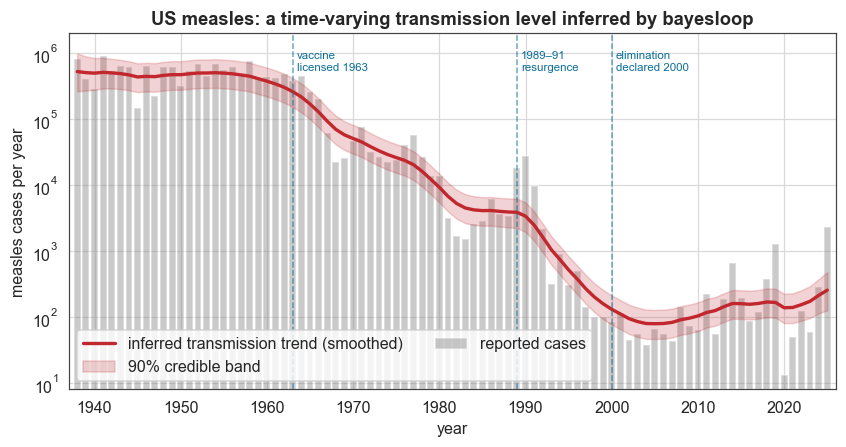

In [4]:
Ssm = bl.Study()
Ssm.load_data(logcases, timestamps=years)
Ssm.set(gaussian_obs(), bl.tm.GaussianRandomWalk("sigma", 0.10, target="mean"))
Ssm.fit(silent=True)
mean_sm, lo_sm, hi_sm = posterior_band(Ssm, "mean")

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(years, cases, width=0.8, color=C["data"], alpha=0.45, label="reported cases")
ax.plot(years, 10 ** mean_sm, color=C["accent"], lw=2.2,
        label="inferred transmission trend (smoothed)")
ax.fill_between(years, 10 ** lo_sm, 10 ** hi_sm, color=C["accent"], alpha=0.20,
                label="90% credible band")
ax.set_yscale("log")
ax.set_ylim(8, 2e6)
ax.set_xlim(1937, 2026)
for yr, lab in [(1963, "vaccine\nlicensed 1963"), (1989, "1989–91\nresurgence"),
                (2000, "elimination\ndeclared 2000")]:
    ax.axvline(yr, color=C["accent2"], ls="--", lw=1, alpha=0.6)
    ax.text(yr + 0.5, 1.1e6, lab, fontsize=7.5, color=C["accent2"], va="top")
ax.set_ylabel("measles cases per year")
ax.set_xlabel("year")
ax.set_title("US measles: a time-varying transmission level inferred by bayesloop")
ax.legend(loc="lower left", ncol=2)
plt.show()

The inferred trend reproduces the modern history of US measles: the pre-vaccine plateau
near 5 × 10⁵ cases/year, the post-1963 collapse, the 1989–91 resurgence (resolved as a
temporary bump), the drive to elimination, and the recent resurgence.

## Letting the evidence choose between abrupt and gradual change

The picture above assumes gradual drift. Whether the data actually prefer that over the
alternatives is a question we can answer directly. Because every model below shares the
identical observation model and data, their log₁₀ marginal likelihoods
(`S.log10_evidence`) are directly comparable. We compare four hypotheses:

| Hypothesis | Transition model |
|---|---|
| Static (null) | `tm.Static()` |
| Abrupt change-point | `tm.ChangePoint("t_change", "all")` |
| Gradual random walk | `tm.GaussianRandomWalk` (the HyperStudy above) |
| Change-point + drift | `CombinedTransitionModel(ChangePoint, GaussianRandomWalk)` |

In [5]:
# M0 — Static (constant level): the null hypothesis.
S0 = bl.Study()
S0.load_data(logcases, timestamps=years)
S0.set(gaussian_obs(), bl.tm.Static())
S0.fit(silent=True)

# M1 — a single abrupt change-point. ChangepointStudy scans *every* possible break year.
S1 = bl.ChangepointStudy()
S1.load_data(logcases, timestamps=years)
S1.set(gaussian_obs(), bl.tm.ChangePoint("t_change", "all"))
S1.fit(silent=True)
cp_x, cp_p = S1.get_hyper_parameter_distribution("t_change")
cp_mode = float(cp_x[np.argmax(cp_p)])
order = np.argsort(cp_p)[::-1]
cred = np.sort(cp_x[order[:np.searchsorted(np.cumsum(cp_p[order]), 0.90) + 1]])

# M3 — an abrupt break superimposed on gradual drift.
S3 = bl.ChangepointStudy()
S3.load_data(logcases, timestamps=years)
S3.set(gaussian_obs(),
       bl.tm.CombinedTransitionModel(
           bl.tm.ChangePoint("t_change", "all"),
           bl.tm.GaussianRandomWalk("sigma", 0.15, target="mean")))
S3.fit(silent=True)

evidence = {
    "Static (constant)": float(S0.log10_evidence),
    "Abrupt change-point": float(S1.log10_evidence),
    "Gradual random walk": evidence_gradual,
    "Change-point + drift": float(S3.log10_evidence),
}
best = max(evidence, key=evidence.get)
print("Model evidence (log10, higher is better):")
for k, v in evidence.items():
    print(f"  {k:24s} {v:9.2f}")
print(f"  --> best: {best}")
print(f"Change-point mode: {cp_mode:.0f} (90% credible {cred.min():.0f}-{cred.max():.0f})")

+ Created new study.
+ Successfully imported array.
+ Observation model: Gaussian observations. Parameter(s): ['mean', 'std']
+ Transition model: Static/constant parameter values. Hyper-Parameter(s): []
+ Created new study.
  --> Hyper-study
  --> Change-point analysis
+ Successfully imported array.
+ Observation model: Gaussian observations. Parameter(s): ['mean', 'std']
+ Transition model: Change-point. Hyper-Parameter(s): ['t_change']
+ Detected 1 change-point(s) in transition model: ['t_change']
+ Set hyper-prior(s): ['uniform']


+ Created new study.
  --> Hyper-study
  --> Change-point analysis
+ Successfully imported array.
+ Observation model: Gaussian observations. Parameter(s): ['mean', 'std']
+ Transition model: Combined transition model. Hyper-Parameter(s): ['t_change', 'sigma']
+ Detected 1 change-point(s) in transition model: ['t_change']
+ Set hyper-prior(s): ['uniform', 'uniform']


Model evidence (log10, higher is better):
  Static (constant)           -78.56
  Abrupt change-point         -47.12
  Gradual random walk         -22.16
  Change-point + drift        -25.16
  --> best: Gradual random walk
Change-point mode: 1966 (90% credible 1965-1966)


The gradual random walk wins by a wide margin. It is many orders of magnitude more
probable than a single abrupt change-point, and adding a change-point on top of the
drift makes the model worse, as the Occam penalty for the extra parameter is not
repaid. The scientific reading is clear and non-trivial: the vaccine's epidemiological
footprint is not a single clean break but a sustained, multi-decade decline as coverage
ratcheted up.

When we nonetheless force a single change-point, the posterior dates the dominant break
to within a couple of years of the 1963 licensing, the lag expected for mass uptake,
and gives a credible interval for it, which a fixed before/after split never could.

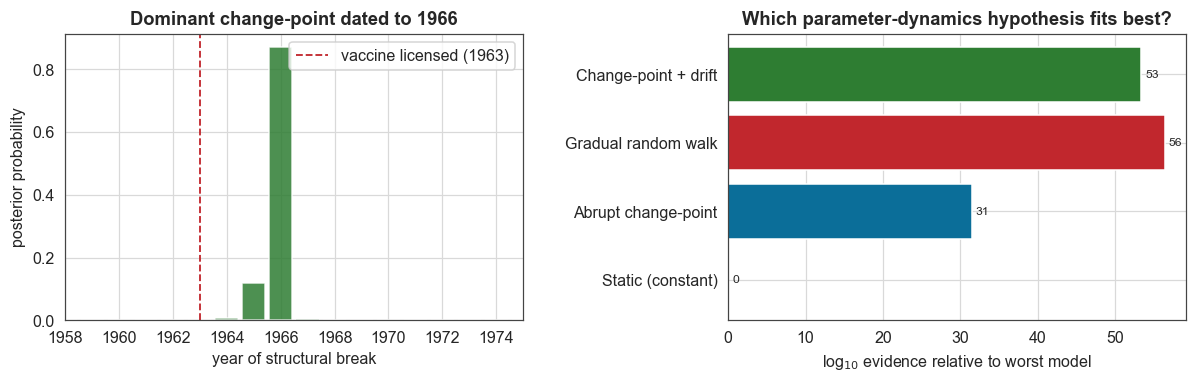

In [6]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 3.6))

# change-point posterior
axL.bar(cp_x, cp_p, width=0.85, color=C["green"], alpha=0.85)
axL.set_xlim(1958, 1975)
axL.axvline(1963, color=C["accent"], ls="--", lw=1.2, label="vaccine licensed (1963)")
axL.set_xlabel("year of structural break")
axL.set_ylabel("posterior probability")
axL.set_title(f"Dominant change-point dated to {cp_mode:.0f}")
axL.legend()

# evidence comparison
labels = list(evidence)
vals = np.array([evidence[k] for k in labels])
vals_rel = vals - vals.min()
bars = axR.barh(labels, vals_rel, color=[C["data"], C["accent2"], C["accent"], C["green"]])
axR.set_xlabel(r"log$_{10}$ evidence relative to worst model")
axR.set_title("Which parameter-dynamics hypothesis fits best?")
for b, v in zip(bars, vals_rel):
    axR.text(v + max(vals_rel) * 0.01, b.get_y() + b.get_height() / 2,
             f"{v:.0f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

### Robustness of the gradual model

One concern is whether the gradual model won only because it was allowed to over-fit.
We check this by comparing the heavily regularised smoothed fit (small fixed step)
against the alternatives, and by trying a heavier-tailed `AlphaStableRandomWalk` that
permits occasional large jumps rather than uniform Gaussian steps (a 2-D `HyperStudy`
over the scale `c` and the tail index `alpha`).

In [7]:
Sas = bl.HyperStudy()
Sas.load_data(logcases, timestamps=years)
Sas.set(gaussian_obs(),
        bl.tm.AlphaStableRandomWalk("c", bl.cint(0.01, 0.5, 10),
                                    "alpha", bl.cint(1.1, 2.0, 8), target="mean"))
Sas.fit(silent=True, n_jobs=4)
a_x, a_p = Sas.get_hyper_parameter_distribution("alpha")
print(f"Regularised smooth fit (sigma=0.10): log10 evidence = {Ssm.log10_evidence:7.2f}")
print(f"Alpha-stable random walk:            log10 evidence = {Sas.log10_evidence:7.2f}"
      f"  (tail index alpha mode = {a_x[np.argmax(a_p)]:.2f})")

+ Created new study.
  --> Hyper-study
+ Successfully imported array.
+ Observation model: Gaussian observations. Parameter(s): ['mean', 'std']
+ Transition model: Alpha-stable random walk. Hyper-Parameter(s): ['c', 'alpha']


Regularised smooth fit (sigma=0.10): log10 evidence =  -29.17
Alpha-stable random walk:            log10 evidence =  -19.84  (tail index alpha mode = 1.74)


Even the regularised fit comfortably beats the single change-point, so the win comes
from the sustained, multi-decade nature of the decline rather than from over-fitting.
The alpha-stable model fits best of all, with a tail index `alpha` well below 2,
indicating that the decline is best described by occasional large jumps on top of
gentle drift.

We can also quote a model-free magnitude straight from the raw series:

In [8]:
pre = float(np.mean(cases[(years >= 1938) & (years <= 1962)]))
lowmask = (years >= 1980) & (years <= 1985)
trough = float(cases[lowmask].min())
trough_year = float(years[lowmask][np.argmin(cases[lowmask])])
print(f"Pre-vaccine mean (1938-1962): {pre:,.0f} cases/yr")
print(f"Early-1980s trough ({trough_year:.0f}): {trough:,.0f} cases")
print(f"=> {pre/trough:,.0f}-fold reduction")

Pre-vaccine mean (1938-1962): 532,633 cases/yr
Early-1980s trough (1983): 1,497 cases
=> 356-fold reduction


## The post-elimination era: a custom Poisson observation model

After elimination the counts are small enough (tens to a couple thousand) to model
directly as Poisson rather than on the log scale. This is also an occasion to show
*bayesloop*'s extensibility. Its built-in Poisson evaluates the pmf directly, which
overflows for counts above about 170, so we supply a numerically stable log-space
Poisson as a one-line `bl.om.NumPy` custom model. We pair it with a `RegimeSwitch`
transition, which lets the rate jump abruptly and is well suited to detecting outbreaks
against the near-zero eliminated baseline.

In [9]:
from scipy.special import gammaln

def poisson_stable(data, rate):
    k = float(data)
    return np.exp(k * np.log(rate) - rate - gammaln(k + 1.0))

modern = us[(us["Year"] >= 1998) & (us["Year"] <= 2025)].reset_index(drop=True)
myears = modern["Year"].values.astype(float)
mcases = modern["cases"].values.astype(float)

Sp = bl.Study()
Sp.load_data(mcases, timestamps=myears)
Sp.set(bl.om.NumPy(poisson_stable, "rate", bl.oint(0, 3000, 1500)),
       bl.tm.RegimeSwitch("log10p_min", -4))
Sp.fit()

rate_mean, rate_lo, rate_hi = posterior_band(Sp, "rate")
baseline = float(np.median(rate_mean[(myears >= 1998) & (myears <= 2017)]))
p_outbreak = prob_above(Sp, "rate", 5 * baseline)   # P(rate > 5x baseline)
for y in (2019, 2025):
    print(f"  {y}: {int(mcases[myears == y][0]):>5d} cases, "
          f"P(rate > 5x baseline) = {p_outbreak[myears == y][0]:.2f}")

+ Created new study.
+ Successfully imported array.
+ Observation model: poisson_stable. Parameter(s): ('rate',)
+ Transition model: Regime-switching model. Hyper-Parameter(s): ['log10p_min']
+ Started new fit:
    + Formatted data.
    + Cached observation likelihoods (0.3 MiB).
    + Set uniform prior with parameter boundaries.


    + Finished forward pass.
    + Log10-evidence: -93.44755


    + Finished backward pass.
    + Computed mean parameter values.
  2019:  1274 cases, P(rate > 5x baseline) = 1.00
  2025:  2288 cases, P(rate > 5x baseline) = 1.00


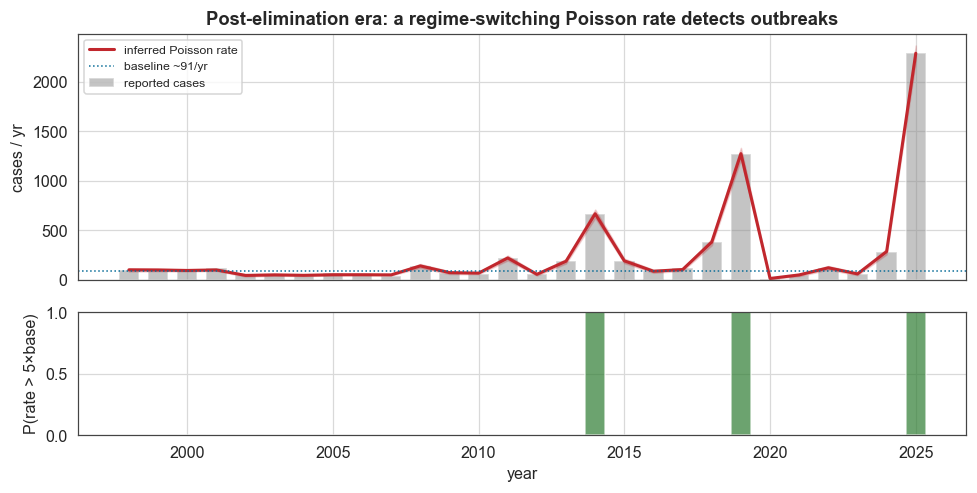

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 4.6), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})
ax1.bar(myears, mcases, width=0.7, color=C["data"], alpha=0.5, label="reported cases")
ax1.plot(myears, rate_mean, color=C["accent"], lw=2, label="inferred Poisson rate")
ax1.fill_between(myears, rate_lo, rate_hi, color=C["accent"], alpha=0.2)
ax1.axhline(baseline, color=C["accent2"], ls=":", lw=1, label=f"baseline ~{baseline:.0f}/yr")
ax1.set_ylabel("cases / yr")
ax1.set_title("Post-elimination era: a regime-switching Poisson rate detects outbreaks")
ax1.legend(loc="upper left", fontsize=8)
ax2.bar(myears, p_outbreak, width=0.7, color=C["green"], alpha=0.7)
ax2.set_ylabel("P(rate > 5×base)")
ax2.set_xlabel("year")
ax2.set_ylim(0, 1)
plt.tight_layout()
plt.show()

The regime-switching Poisson flags the 2019 and 2025 outbreaks at posterior probability
≈ 1.0 against the eliminated baseline.

## What this example showed

On a single dataset we used *bayesloop* to:

- answer a scientific question with model evidence: the choice between abrupt and
  gradual change is settled quantitatively, and the answer (gradual) is the less
  obvious one;
- recover a dated transition with a credible interval, without telling the model when
  the vaccine arrived;
- exercise the toolbox end-to-end, using `Study`, `HyperStudy` and `ChangepointStudy`,
  the `Gaussian` and custom `NumPy` observation models, and a range of transition
  models including a custom numerically-stable Poisson and a regime switch.

Every number cross-checks against the published epidemiological record: a ~1966
dominant transition, the early-1980s trough, the ~356-fold drop, the 1989–91
resurgence, and the 2019/2025 outbreaks.